#Preparing the datset

In [1]:
!pip install googletrans==4.0.0-rc1

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.1/55.1 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.4/133.4 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.0/65.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 34.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.6/53.6 kB 2.3 MB/s eta 0:00:00
  Created wheel for googletrans: filename=googletrans-4.0.0rc1-py3-none-any.whl size=17396 sha256=0f3677675d80ea7f26ef854c03d31a7154f588a9040db3709867b800f771acc4
  Stored in directory: /root/.cache/pip/wheels/95/0f/04/b17a72024b56a60e499ce1a6313d283ed5ba332407155bee03
Successfully built googletrans
  Attempting uninstall: hyperframe
    Found existing installation: hyperframe 6.1.0
    Uninstalling hyperfram

In [2]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
import plotly.graph_objects as go

from googletrans import Translator

In [3]:
# Connect to Google Drive
from google.colab import drive
drive.mount('/drive')
!ls '/drive/MyDrive/Colab Notebooks/Im_Wald_Project'

Mounted at /drive
'mi_advertising & media_entertainment_germany_usd_en_2025-5-19_06-50-32.csv'
 mi_consumer_toys-hobby_germany_usd_en_2025-5-19_06-49-17.csv
 mi_mobility_travel-tourism_germany_usd_en_2025-5-19_06-51-39.csv
 PEDROALVES_Code_ImWald04.ipynb
 Regression_Task
 statistic_id1198412_umfrage-zu-den-umweltbeeintraechtigungen-im-wandertourismus-in-deutschland-in-2020.xlsx
 statistic_id1466155_positive-effekte-des-tourismus-auf-den-eigenen-wohnort-in-deutschland-2024.xlsx
 statistic_id171168_deutschlands-beliebteste-hobbys-freizeitaktivitaeten-und-sportarten-bis-2024.xlsx
 statistic_id301281_einkommensverteilung-der-intensivwandereisenden-2012.xlsx
'statistic_id572415_hiking-tourists-in-germany-2013-by-age-group (1).xlsx'
 statistic_id572415_hiking-tourists-in-germany-2013-by-age-group.xlsx
 statistic_id748496_umfrage-unter-camping-urlaubern-in-deutschland-zum-natur--und-umweltschutz-2024.xlsx
 statistic_id750827_private-households-in-germany-2023-by-net-income-level.xlsx
 study_i

In [4]:
# Importing the files
concerns = pd.read_excel('/drive/MyDrive/Colab Notebooks/Im_Wald_Project/statistic_id1198412_umfrage-zu-den-umweltbeeintraechtigungen-im-wandertourismus-in-deutschland-in-2020.xlsx',
                     sheet_name='Daten', skiprows=4)[['Unnamed: 1', 'Unnamed: 2']]
concerns = concerns.rename(columns={'Unnamed: 1': 'Main concerns', 'Unnamed: 2': 'Number of responses'})
concerns

camping = pd.read_csv('/drive/MyDrive/Colab Notebooks/Im_Wald_Project/mi_mobility_travel-tourism_germany_usd_en_2025-5-19_06-51-39.csv')
camping

equipments = pd.read_csv('/drive/MyDrive/Colab Notebooks/Im_Wald_Project/mi_consumer_toys-hobby_germany_usd_en_2025-5-19_06-49-17.csv')
equipments

national_parks = pd.read_csv('/drive/MyDrive/Colab Notebooks/Im_Wald_Project/mi_advertising & media_entertainment_germany_usd_en_2025-5-19_06-50-32.csv')
national_parks

pos_impact = pd.read_excel('/drive/MyDrive/Colab Notebooks/Im_Wald_Project/statistic_id1466155_positive-effekte-des-tourismus-auf-den-eigenen-wohnort-in-deutschland-2024.xlsx',
                     sheet_name='Daten', skiprows=4)[['Unnamed: 1', 'Unnamed: 2']]
pos_impact = pos_impact.rename(columns={'Unnamed: 1': 'Main impact', 'Unnamed: 2': 'Number of responses (in %)'})
pos_impact

hobbys = pd.read_excel('/drive/MyDrive/Colab Notebooks/Im_Wald_Project/statistic_id171168_deutschlands-beliebteste-hobbys-freizeitaktivitaeten-und-sportarten-bis-2024.xlsx',
                     sheet_name='Daten', skiprows=4)[['Unnamed: 1', '2022', '2023', '2024']]
hobbys = hobbys.rename(columns={'Unnamed: 1': 'Hobbys'})
hobbys

age_group = pd.read_excel('/drive/MyDrive/Colab Notebooks/Im_Wald_Project/statistic_id572415_hiking-tourists-in-germany-2013-by-age-group.xlsx',
                     sheet_name='Data', skiprows=4)[['Unnamed: 1', 'Unnamed: 2']]
age_group = age_group.rename(columns={'Unnamed: 1': 'Age group', 'Unnamed: 2': 'Number of responses'})
age_group

eco_conscious = pd.read_excel('/drive/MyDrive/Colab Notebooks/Im_Wald_Project/statistic_id748496_umfrage-unter-camping-urlaubern-in-deutschland-zum-natur--und-umweltschutz-2024.xlsx',
                              sheet_name='Daten', skiprows=4)[['Unnamed: 1', 'Camping-Urlauber', 'Deutsche Bevölkerung']]
eco_conscious = eco_conscious.rename(columns={'Unnamed: 1': 'Interest on environmental protection'})
eco_conscious

hikers_income = pd.read_excel('/drive/MyDrive/Colab Notebooks/Im_Wald_Project/statistic_id301281_einkommensverteilung-der-intensivwandereisenden-2012.xlsx',
                              sheet_name='Daten', skiprows=4)[['Unnamed: 1', 'Unnamed: 2']]
hikers_income = hikers_income.rename(columns={'Unnamed: 1': 'Income level', 'Unnamed: 2': 'Number of responses'})
hikers_income

german_income = pd.read_excel('/drive/MyDrive/Colab Notebooks/Im_Wald_Project/statistic_id750827_private-households-in-germany-2023-by-net-income-level.xlsx',
                              sheet_name='Data', skiprows=4)[['Unnamed: 1', 'Unnamed: 2']]
german_income = german_income.rename(columns={'Unnamed: 1': 'Income level', 'Unnamed: 2': 'Number of households'})
german_income


,Income level,Number of households
0,Under 500 euros,577
1,"500 to less than 1,000 euros",2556
2,"1,000 to 1,250 euros",2238
3,"1,250 to less than 1,500 euros",2114
4,"1,500 to less than 2,000 euros",5182
5,"2,000 to less than 2,500 euros",5458
6,"2,500 to less than 3,000 euros",4176
7,"3,000 to less than 3,500 euros",3675
8,"3,500 to less than 4,000 euros",3073
9,"4,000 to less than 5,000 euros",4743


In [5]:
# Translating German files
translator = Translator()

concerns['Main concerns'] = concerns['Main concerns'].apply(lambda x: translator.translate(x, dest='en').text)
pos_impact['Main impact'] = pos_impact['Main impact'].apply(lambda x: translator.translate(x, dest='en').text)
hobbys['Hobbys'] = hobbys['Hobbys'].apply(lambda x: translator.translate(x, dest='en').text)
eco_conscious['Interest on environmental protection'] = eco_conscious['Interest on environmental protection'].apply(lambda x: translator.translate(x, dest='en').text)

#Part 1: Who are the hikers in Germany?

In [6]:
color_hex = '#396657'

fig = go.Figure()

# Adds each column to the scatter plot
for col in hobbys.columns[1:]:
  fig.add_trace(go.Scatter(x=hobbys['Hobbys'], y=hobbys[col], mode='lines+markers', name=col, marker_color=color_hex))

# Creates an updatable scatterplot, where there is a list (dropdown menu) with options
# of years, and the user can look different periods.
# The buttons for the dropdown menu are in the dictionary of arguments in the list.
fig.update_layout(
    updatemenus=[
        go.layout.Updatemenu(
            active=0,
            buttons=list([
                dict(label=col,
                     method='update',
                     args=[{'visible': [col == c for c in hobbys.columns[1:]]},
                           {'title': f'Hobbys over time ({col})',
                            'fontsize':20}])
                for col in hobbys.columns[1:]
            ])
        )
    ],
    title_text='Select a year',
    plot_bgcolor='lightgray'

)
# fig.update_layout(title_text='Select a year')
fig.show()

In [7]:
import matplotlib.colors as mcolors

age_plot = age_group
age_plot = age_plot.set_index('Age group')

color_hex = '#cc7b39'

fig = go.Figure(data=[go.Bar(
    x=age_plot.index,
    y=age_plot['Number of responses'],
    hovertemplate='<b>Age Group:</b> %{x}<br><b>Responses:</b> %{y}<extra></extra>',
    marker_color=color_hex,
)])

fig.update_layout(
     title={
        'text': 'Age group of the hikers',
        'font': {'size': 18}
    },
    xaxis_title={
        'text': 'Age group',
        'font': {'size': 14}
        },
    yaxis_title={
        'text': 'Number of responses (in %)',
        'font': {'size': 14}
    },
    xaxis={'tickfont': {'size': 14}},  # Increase x-axis tick label font size
    yaxis={'tickfont': {'size': 14}}   # Increase y-axis tick label font size
)

fig.show()

In [8]:
# Showing the total and relative number of household income
total_households = german_income['Number of households'].sum()

# For each income level, takes the number of household and divides it by total households
german_income['Relative'] = (german_income['Number of households'] / total_households) *100

# print(german_income)

#Sums the relative income for households with $3.500 or more of income
sum(german_income['Relative'][8:])

37.12847323070965

          Income level  Number of responses
0        Unter 1.750 €                   19
1  1.750 € bis 2.249 €                   15
2  2.250 € bis 3.249 €                   26
3     3.250 € und mehr                   40


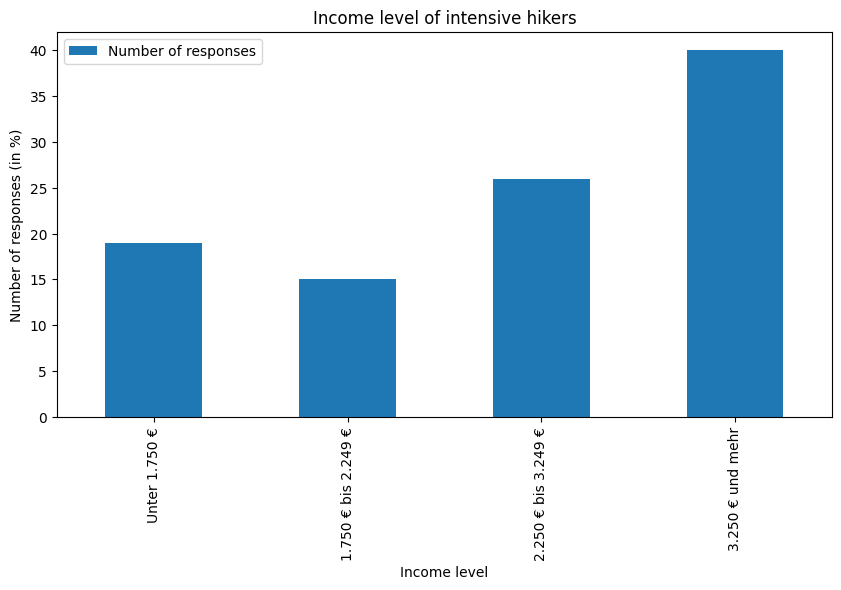

In [9]:
print(hikers_income)
inc_barplot = hikers_income
inc_barplot = inc_barplot.set_index('Income level')

inc_barplot.plot(kind='bar', figsize=(10,5))
plt.title('Income level of intensive hikers')
plt.xlabel('Income level')
plt.ylabel('Number of responses (in %)')
plt.show()

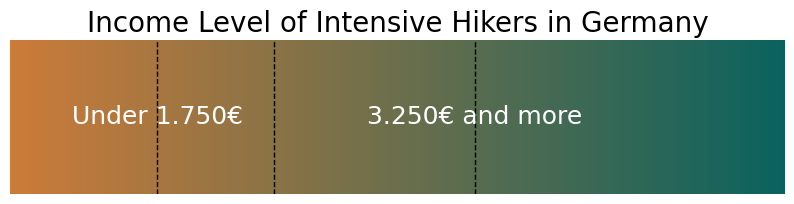

In [10]:
import matplotlib.patches as patches
import matplotlib.colors as mcolors

# Define the colors' hex code
start_color_hex = '#cc7b39'
end_color_hex = '#0a625e'

# Convert hex code to RGB
start_color = mcolors.to_rgb(start_color_hex)
end_color = mcolors.to_rgb(end_color_hex)

# Define the number of steps for the gradient
n_steps = 265

# Create a gradient of colors
colors = [((1-t)*np.array(start_color) + t*np.array(end_color)) for t in np.linspace(0, 1, n_steps)]

fig, ax = plt.subplots(figsize=(10, 2))
bar_width = 1
bar_height = 1

# Draw small rectangles with fading colors
for i in range(n_steps):
    rect = patches.Rectangle((i/n_steps * bar_width, 0), bar_width/n_steps, bar_height,
                             linewidth=0, edgecolor=None, facecolor=colors[i])
    ax.add_patch(rect)

# Set axis limits and hide the axes
ax.set_xlim(0, bar_width)
ax.set_ylim(0, bar_height)
ax.axis('off')

data_points = [0.19, 0.34,  0.6] # Example positions on the bar (between 0 and 1)
data_labels = ['Under 1.750€', '', '3.250€ and more'] # Labels for the points

# Add marks and labels to the fade bar
for i, point in enumerate(data_points):
    # Add a vertical line to mark the data point
    ax.plot([point, point], [0, bar_height], color='black', linestyle='--', linewidth=1)

    # Add a label near the data point
    ax.text(point, bar_height * 0.5, data_labels[i], ha='center', va='center', fontsize=18, color='white')


plt.title('Income Level of Intensive Hikers in Germany', fontsize=20)
plt.show()

# Part 2: Ecological consciousness and ecological impacts

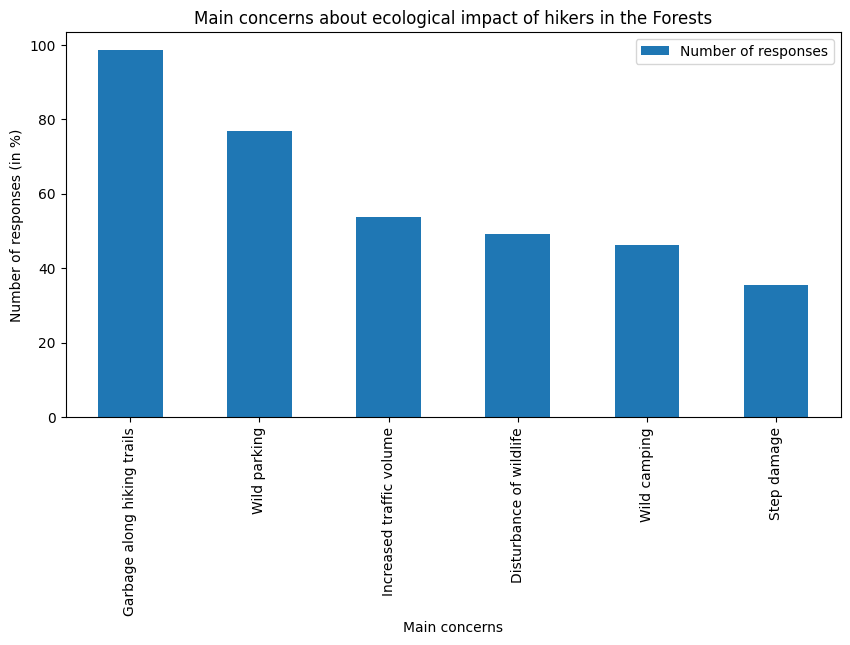

In [11]:
barcolumn = concerns
barcolumn = barcolumn.set_index('Main concerns')

barcolumn.plot(kind='bar', figsize=(10, 5))
plt.title('Main concerns about ecological impact of hikers in the Forests')
plt.xlabel('Main concerns')
plt.ylabel('Number of responses (in %)')
plt.show()

In [12]:
import plotly.express as px

pie_colors = ['#768e45', '#574338', '#2a3833', '#cc7b39', '#bf5051', '#d2d2d2']

fig = px.pie(concerns, values='Number of responses', names='Main concerns',
             title='Main concerns about ecological impact of hikers in the Forests',
             color_discrete_sequence=pie_colors)
fig.show()


                Interest on environmental protection  Camping-Urlauber  \
0                                 Interested overall              81.8   
1                            Particularly interested              33.3   
2                 Also interested, but not that much              48.5   
3                      Hardly, not at all interested              18.2   
4  Interested and - give advice and tips more oft...              16.2   
5  I often find out more about this topic on the ...              21.3   

   Deutsche Bevölkerung  
0                  75.0  
1                  24.7  
2                  50.3  
3                  25.0  
4                  10.6  
5                  12.5  


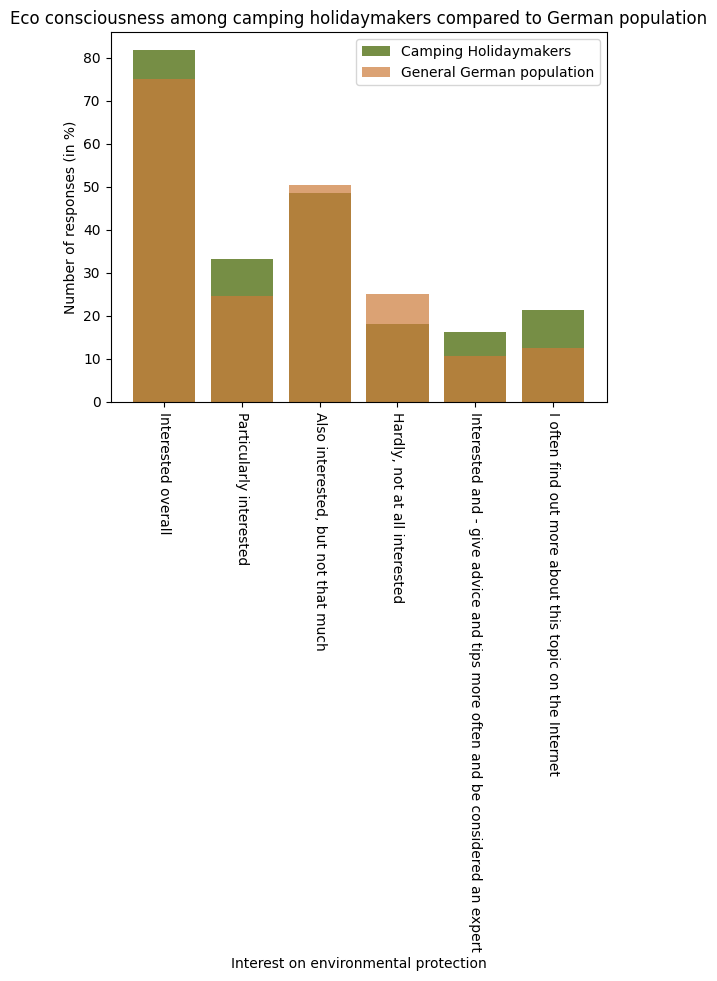

In [13]:
print(eco_conscious)
plt.bar(eco_conscious['Interest on environmental protection'], eco_conscious['Camping-Urlauber'], label='Camping Holidaymakers', color='#768e45')
plt.bar(eco_conscious['Interest on environmental protection'], eco_conscious['Deutsche Bevölkerung'], label='General German population', alpha=0.7, color='#cc7b39')
plt.title('Eco consciousness among camping holidaymakers compared to German population')
plt.xlabel('Interest on environmental protection')
plt.ylabel('Number of responses (in %)')
plt.xticks(rotation=270)
plt.legend()
plt.show()

# Part 3: Economic impacts

In [14]:
# Selecting the revenue and revenue change of the German camping market
market_germany = camping.loc[0:1]

for index, row in market_germany.iterrows():
  german_change = []
  sum_german_change = 0

  # Calculating the total change in revenue in Germany
  if index == 0:
    for row_name, value in row.items():
      if row_name in ('2017','2018', '2019', '2020', '2021', '2022', '2023',
                      '2024', '2025', '2026', '2027', '2028', '2029'):
        value = value.replace(',','')
        value = float(value)
        print(f"Row: {row_name}")
        print(f"Row value: {value}")
        row[row_name] = value
    rev_mrkt_germany = row.copy()

  else:
    for row_name, value in row.items():
      if row_name in ('2017','2018', '2019', '2020', '2021', '2022', '2023',
                      '2024', '2025', '2026', '2027', '2028', '2029'):
        value = float(value)
        print(f"Row: {row_name}")
        print(f"Row value: {value}")
        sum_german_change += value
  sum_german_change = round(sum_german_change, 3)
  print(sum_german_change)


print(rev_mrkt_germany)





Row: 2017
Row value: 450367309.108
Row: 2018
Row value: 481295155.425
Row: 2019
Row value: 507296847.197
Row: 2020
Row value: 595295607.134
Row: 2021
Row value: 580703278.666
Row: 2022
Row value: 506826949.878
Row: 2023
Row value: 533726453.332
Row: 2024
Row value: 552660737.498
Row: 2025
Row value: 577355858.168
Row: 2026
Row value: 599576628.622
Row: 2027
Row value: 620400750.135
Row: 2028
Row value: 639862530.664
Row: 2029
Row value: 659508150.517
0
Row: 2017
Row value: 0.0
Row: 2018
Row value: 0.069
Row: 2019
Row value: 0.054
Row: 2020
Row value: 0.173
Row: 2021
Row value: -0.025
Row: 2022
Row value: -0.127
Row: 2023
Row value: 0.053
Row: 2024
Row value: 0.035
Row: 2025
Row value: 0.045
Row: 2026
Row value: 0.038
Row: 2027
Row value: 0.035
Row: 2028
Row value: 0.031
Row: 2029
Row value: 0.031
0.412
Region                     Germany
Market                     Camping
Brand                          NaN
Chart                      Revenue
Name                         Total
Unit       

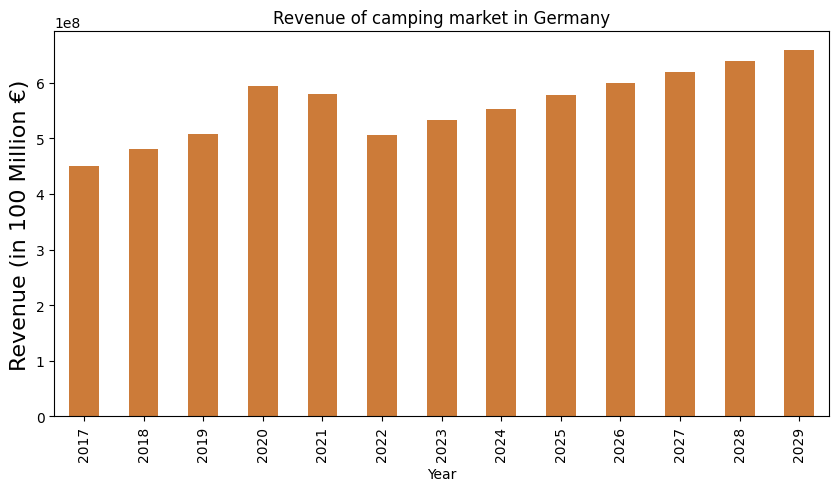

In [15]:
revenue_bar = rev_mrkt_germany[7:]
revenue_bar.plot(kind='bar', figsize=(10,5), color='#cc7b39')
plt.title('Revenue of camping market in Germany')
plt.xlabel('Year')
plt.ylabel('Revenue (in 100 Million €)', fontsize=16)
plt.show()

In [16]:
# Calculate average increase in camping market revenue in all studied countries
countries = camping[17:166]
change_list = []
total_change = []
# iterrows converts each row of the column into a tuple with 2 elements: the index and the row Series
# Here, I'm unpacking the tuple
for index, row in countries.iterrows():
  sum_change = 0
  # I'm unpacking the tuple once more by row
  for row_name, value in row.items():
    change = 0
    # prv_value = 0
    if row_name in ('2017','2018', '2019', '2020', '2021', '2022', '2023', '2024',
                    '2025', '2026', '2027', '2028', '2029'):
      # Converting string into float
      value_wtht_comma = value.replace(',','')
      value_float = float(value_wtht_comma)
      print(f"Row: {row_name}")
      print(f"Row value: {value_float}")

      # Calculating the change year by year
      if row_name == '2017':
        crnt_value = value_float
        prv_value = value_float
        change = crnt_value - prv_value
        rltv_change = round(change/prv_value,3)
        sum_change += rltv_change
        sum_change = round(sum_change,3)
        print(f'Previous value = {prv_value}')
        print(f'Current value = {crnt_value}')
        print(f'Change = {change}')
        print(f'Relative change (%) = {rltv_change}')


      else:
        crnt_value = value_float
        change = crnt_value - prv_value
        rltv_change = round(change/prv_value,3)
        sum_change += rltv_change
        sum_change = round(sum_change,3)
        print(f'Previous value = {prv_value}')
        print(f'Current value = {crnt_value}')
        print(f'Change = {change}')
        print(f'Relative change (%) = {rltv_change}')
        prv_value = crnt_value

  total_change.append(sum_change)

  # Comparing the changes in each country to Germany and then adding a new column
  # with this value
  comprd_change = sum_change - sum_german_change
  comprd_change = round(comprd_change,3)
  change_list.append(comprd_change)
  print('-'*20)
  print(f'Sum of relative change = {sum_change}')
  print(f'Compared with German change = {comprd_change}')
  print('='*20)
countries['Total change'] = total_change
countries['Compared change'] = change_list
countries

Row: 2017
Row value: 656276636.107
Previous value = 656276636.107
Current value = 656276636.107
Change = 0.0
Relative change (%) = 0.0
Row: 2018
Row value: 690468710.235
Previous value = 656276636.107
Current value = 690468710.235
Change = 34192074.12800002
Relative change (%) = 0.052
Row: 2019
Row value: 754407207.327
Previous value = 690468710.235
Current value = 754407207.327
Change = 63938497.09200001
Relative change (%) = 0.093
Row: 2020
Row value: 332724194.238
Previous value = 754407207.327
Current value = 332724194.238
Change = -421683013.08900005
Relative change (%) = -0.559
Row: 2021
Row value: 465955081.157
Previous value = 332724194.238
Current value = 465955081.157
Change = 133230886.91900003
Relative change (%) = 0.4
Row: 2022
Row value: 702911913.012
Previous value = 465955081.157
Current value = 702911913.012
Change = 236956831.85499996
Relative change (%) = 0.509
Row: 2023
Row value: 751930933.802
Previous value = 702911913.012
Current value = 751930933.802
Change = 49

/tmp/ipykernel_1470/1369060098.py:58: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_1470/1369060098.py:59: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,Region,Market,Brand,Chart,Name,Unit,Source,2017,2018,2019,...,2022,2023,2024,2025,2026,2027,2028,2029,Total change,Compared change
17,Germany,Camping,NaN,Global Comparison - Revenue,Australia,USD (US$),Statista Market Insights,"656,276,636.107","690,468,710.235","754,407,207.327",...,"702,911,913.012","751,930,933.802","799,880,290.146","851,162,104.921","903,288,847.351","958,642,841.268","1,014,318,626.598","1,072,841,524.426",0.931,0.519
18,Germany,Camping,NaN,Global Comparison - Revenue,Canada,USD (US$),Statista Market Insights,"283,313,715.971","273,755,587.592","268,493,942.801",...,"290,415,583.165","303,450,270.576","316,817,994.205","334,221,420.798","349,218,750.056","364,089,407.202","380,386,433.061","400,617,427.719",0.384,-0.028
19,Germany,Camping,NaN,Global Comparison - Revenue,United States,USD (US$),Statista Market Insights,"24,130,619,002.809","23,884,038,670.437","23,645,658,629.502",...,"21,731,453,125.013","24,048,622,361.493","25,809,849,638.434","27,413,430,379.466","29,142,148,060.455","30,969,129,077.002","32,855,680,386.675","34,723,989,829.789",0.396,-0.016
20,Germany,Camping,NaN,Global Comparison - Revenue,Saudi Arabia,USD (US$),Statista Market Insights,"6,357,740.357","6,574,954.684","6,849,235.878",...,"6,732,143.46","7,051,343.876","7,370,544.293","7,689,744.709","8,008,945.126","8,328,145.542","8,647,345.959","8,966,546.375",0.384,-0.028
21,Germany,Camping,NaN,Global Comparison - Revenue,Israel,USD (US$),Statista Market Insights,"11,999,100.743","9,829,335.312","8,295,963.711",...,"12,546,824.271","13,254,456.968","11,481,536.003","13,576,336.385","15,197,885.129","16,989,765.783","17,991,913.949","19,063,996.427",1.549,1.137
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
161,Germany,Camping,NaN,Global Comparison - Revenue,Uruguay,USD (US$),Statista Market Insights,"418,313.563","411,916.861","418,144.19",...,"708,189.889","754,893.33","852,074.402","948,426.041","1,050,768.913","1,159,103.807","1,273,628.198","1,398,792.394",1.374,0.962
162,Germany,Camping,NaN,Global Comparison - Revenue,Uzbekistan,USD (US$),Statista Market Insights,"124,966.885","399,535.536","713,319.515",...,"1,162,341.924","1,399,392.549","1,678,361.165","2,022,633.575","2,391,134.111","2,768,379.917","3,163,548.297","3,586,933.571",4.859,4.447
163,Germany,Camping,NaN,Global Comparison - Revenue,Zambia,USD (US$),Statista Market Insights,"69,522.326","128,232.219","185,271.179",...,"321,426.435","370,917.878","435,944.09","489,276.907","541,993.057","602,588.995","668,972.98","741,793.54",2.789,2.377
164,Germany,Camping,NaN,Global Comparison - Revenue,Albania,USD (US$),Statista Market Insights,"84,010.975","88,089.871","91,299.209",...,"86,028.183","94,662.442","102,465.081","110,267.185","118,721.647","127,860.977","137,974.86","149,034.698",0.633,0.221


In [17]:
# The mean of change through all countries
sum_total_change = round(countries['Total change'].sum(),3)
mean_change = round(sum_total_change/len(countries),3)
print(sum_total_change)
print(mean_change)

316.552
2.125


In [18]:
bar_countries = countries
bar_countries.set_index('Name', inplace=True)

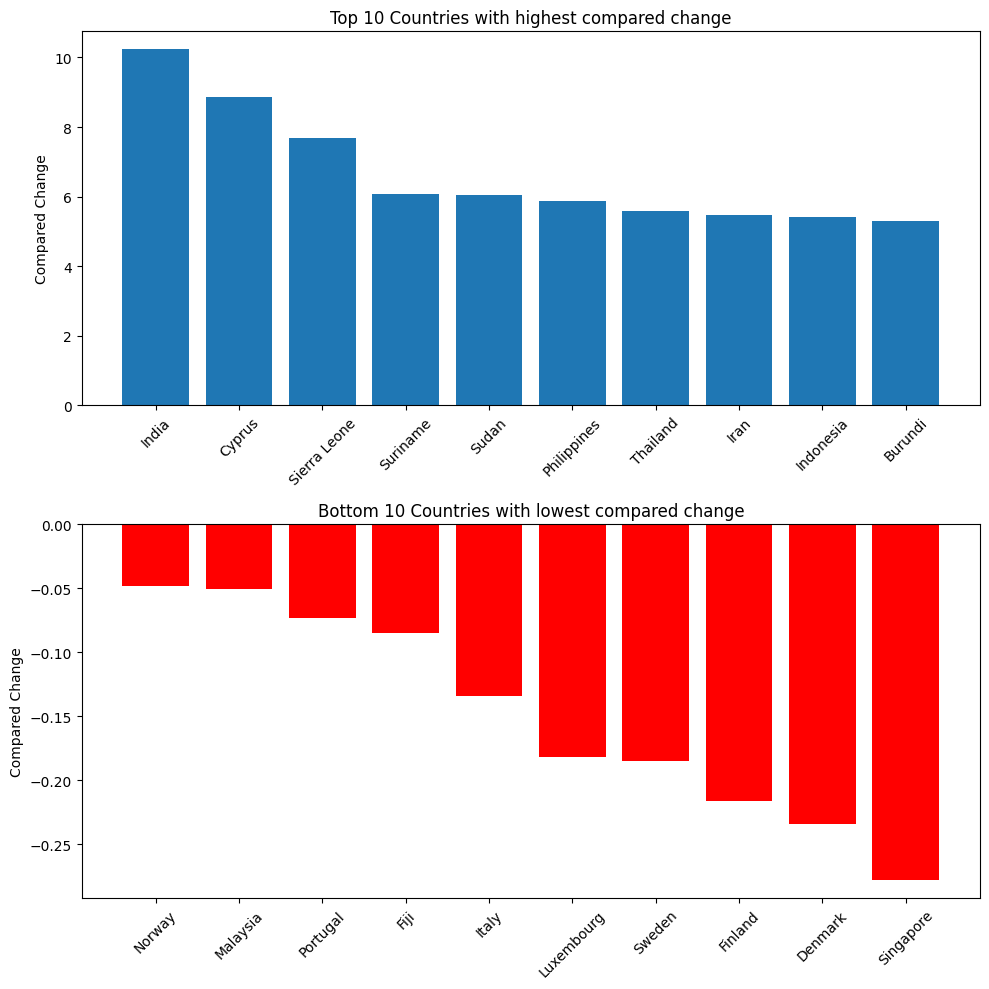

In [19]:
# Sorting the countries by their change in revenue on sport equipments compared to the same change
# in Germany
sorted_countries = bar_countries.sort_values(by='Compared change', ascending=False)
top_10 = sorted_countries.head(10)
bottom_10 = sorted_countries.tail(10)

# Ploting the graph of top 10 and bottom 10 countries
fig, axes = plt.subplots(2, 1, figsize=(10,10))

axes[0].bar(top_10.index, top_10['Compared change'])
axes[0].set_title('Top 10 Countries with highest compared change')
axes[0].set_ylabel('Compared Change')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(bottom_10.index, bottom_10['Compared change'], color='red')
axes[1].set_title('Bottom 10 Countries with lowest compared change')
axes[1].set_ylabel('Compared Change')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


In [20]:
# Taking the first two lines of the National Parks table
revenue_np = national_parks.loc[0:1].copy()
revenue_np

# Converting the values into float
for index, row in revenue_np.iterrows():
  for row_name, value in row.items():
    if row_name in ('2017','2018', '2019', '2020', '2021', '2022', '2023', '2024',
                    '2025', '2026', '2027', '2028', '2029', '2030'):
      value_float = value.replace(',','')
      value_float = float(value_float)
      revenue_np.at[index, row_name] = value_float

revenue_np[5:] = revenue_np[5:].apply(pd.to_numeric)

# Transposing the values from rows to columns
revenue_np_transposed = revenue_np.set_index('Chart').T
revenue_np_transposed


revenue = revenue_np_transposed['Revenue']
revenue_change = revenue_np_transposed['Revenue Change']

print(revenue)
print(revenue_change)


Region                     Germany
Market              National Parks
Name                         Total
Unit                     USD (US$)
Source    Statista Market Insights
2017                  41934521.206
2018                  41773433.013
2019                  42536901.786
2020                  31271030.938
2021                   38840113.73
2022                  35055242.979
2023                  41784579.794
2024                  44009933.822
2025                  46487537.581
2026                  48916756.771
2027                  51343347.871
2028                  53752573.789
2029                   56132245.92
2030                  58556780.891
Name: Revenue, dtype: object
Region                     Germany
Market              National Parks
Name                         Total
Unit                       percent
Source    Statista Market Insights
2017                           0.0
2018                        -0.004
2019                         0.018
2020                      

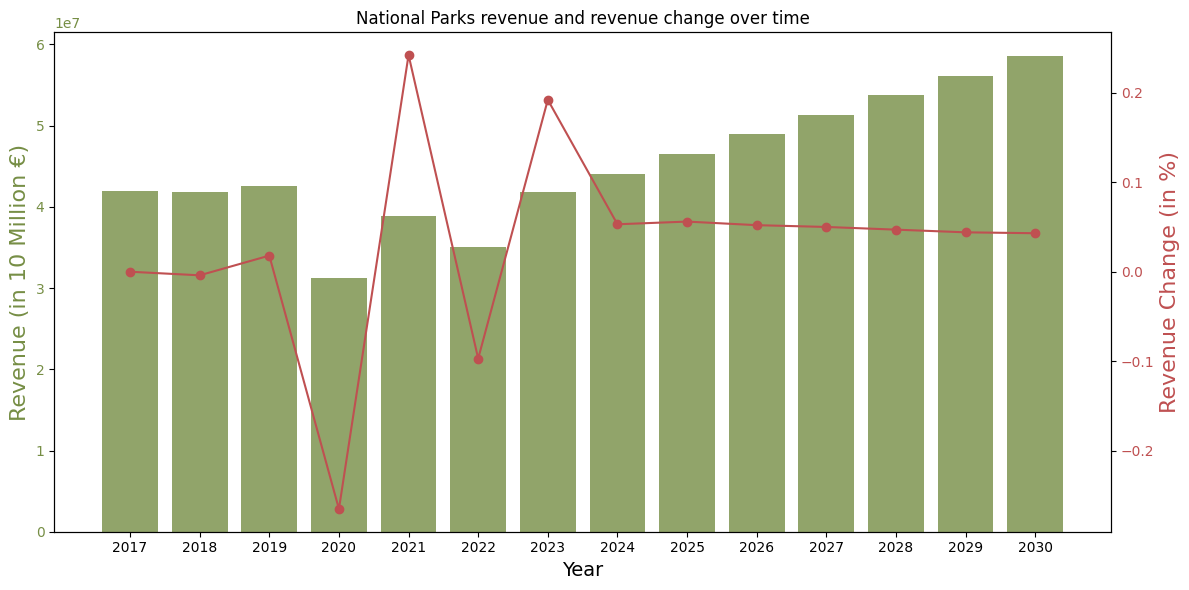

In [21]:
# Plotting line and bar plots, the lines for the revenue
fig, ax1 = plt.subplots(figsize=(12,6))
ax1.bar(revenue[5:].index, revenue[5:].values, color='#768e45', label='Revenue', alpha=0.8)
ax1.set_xlabel('Year', fontsize=14)
ax1.set_ylabel('Revenue (in 10 Million €)', color='#768e45', fontsize=16)
ax1.tick_params(axis='y', labelcolor='#768e45')

ax2 = ax1.twinx()
ax2.plot(revenue_change[5:].index, revenue_change[5:].values, marker='o', color='#bf5051', label='Revenue Change')
ax2.set_ylabel('Revenue Change (in %)', color='#bf5051', fontsize=16)
ax2.tick_params(axis='y', labelcolor='#bf5051')

plt.title('National Parks revenue and revenue change over time')
fig.tight_layout()
plt.show()